# SASRec: Self-Attentive Sequential Recommendation

## Paper

Self-Attentive Sequential Recommendation (SASRec)

Published in ICDM 2018

Authors:
Wang-Cheng Kang, Julian McAuley

---

## Objective

Implement SASRec completely from scratch using MovieLens-100K.

Unlike GRU4Rec and Caser, SASRec replaces recurrent and convolutional
networks with Transformer-style self-attention.

The model learns which previous interactions are most relevant for
predicting the next item.

---

## Pipeline

MovieLens

↓

Sort by Timestamp

↓

User Sequences

↓

Sliding Window

↓

Padding

↓

Item Embedding

+

Position Embedding

↓

Transformer Encoder

↓

Self-Attention

↓

Feed Forward Network

↓

Sequence Representation

↓

Item Scores

↓

Recommendation

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

In [2]:
ratings = pd.read_csv(

    "../data/u.data",

    sep="\t",

    names=[
        "user_id",
        "movie_id",
        "rating",
        "timestamp"
    ]

)

ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [3]:
print("Shape :", ratings.shape)

print()

print(ratings.info())

print()

print("Users :", ratings.user_id.nunique())

print("Movies :", ratings.movie_id.nunique())

Shape : (100000, 4)

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB
None

Users : 943
Movies : 1682


In [4]:
ratings = ratings.sort_values(

    by=[

        "user_id",

        "timestamp"

    ]

).reset_index(

    drop=True

)

In [5]:
user_mapping = {

    u:i

    for i, u in enumerate(

        ratings.user_id.unique()

    )

}

movie_mapping = {

    m:i+1

    for i, m in enumerate(

        ratings.movie_id.unique()

    )

}

ratings["user_id"] = ratings.user_id.map(

    user_mapping

)

ratings["movie_id"] = ratings.movie_id.map(

    movie_mapping

)

PAD_TOKEN = 0

NUM_USERS = ratings.user_id.nunique()

NUM_MOVIES = ratings.movie_id.nunique()

print(NUM_USERS)

print(NUM_MOVIES)

943
1682


In [6]:
user_mapping = {

    u:i

    for i, u in enumerate(

        ratings.user_id.unique()

    )

}

movie_mapping = {

    m:i+1

    for i, m in enumerate(

        ratings.movie_id.unique()

    )

}

ratings["user_id"] = ratings.user_id.map(

    user_mapping

)

ratings["movie_id"] = ratings.movie_id.map(

    movie_mapping

)

PAD_TOKEN = 0

NUM_USERS = ratings.user_id.nunique()

NUM_MOVIES = ratings.movie_id.nunique()

print(NUM_USERS)

print(NUM_MOVIES)

943
1682


In [7]:
user_sequences = (

    ratings

    .groupby(

        "user_id"

    )["movie_id"]

    .apply(list)

)

user_sequences.head()

user_id
0    [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...
1    [273, 251, 274, 275, 276, 277, 278, 279, 280, ...
2    [309, 307, 317, 318, 126, 319, 280, 320, 321, ...
3    [251, 276, 309, 345, 255, 280, 349, 347, 356, ...
4    [127, 250, 363, 40, 364, 365, 17, 9, 38, 204, ...
Name: movie_id, dtype: object

In [8]:
sequence_lengths = user_sequences.apply(len)

sequence_lengths.describe()

count    943.000000
mean     106.044539
std      100.931743
min       20.000000
25%       33.000000
50%       65.000000
75%      148.000000
max      737.000000
Name: movie_id, dtype: float64

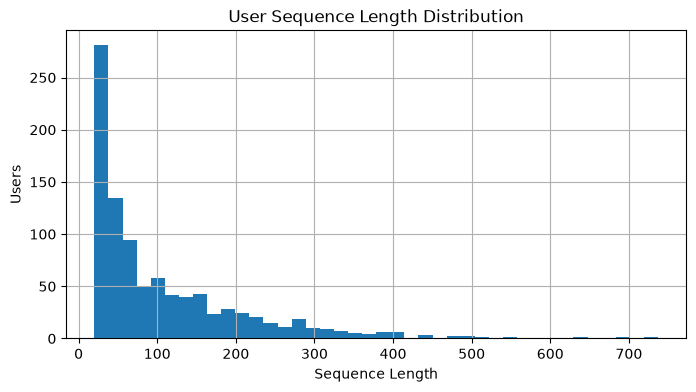

In [9]:
plt.figure(figsize=(8,4))

plt.hist(

    sequence_lengths,

    bins=40

)

plt.xlabel("Sequence Length")

plt.ylabel("Users")

plt.title("User Sequence Length Distribution")

plt.grid(True)

plt.show()

In [10]:
train_sequences = []

targets = []

for sequence in user_sequences:

    if len(sequence) < 2:

        continue

    for i in range(1, len(sequence)):

        train_sequences.append(

            sequence[:i]

        )

        targets.append(

            sequence[i]

        )

In [11]:
for i in range(5):

    print(

        "Input:",

        train_sequences[i]

    )

    print(

        "Target:",

        targets[i]

    )

    print("-"*40)

Input: [1]
Target: 2
----------------------------------------
Input: [1, 2]
Target: 3
----------------------------------------
Input: [1, 2, 3]
Target: 4
----------------------------------------
Input: [1, 2, 3, 4]
Target: 5
----------------------------------------
Input: [1, 2, 3, 4, 5]
Target: 6
----------------------------------------


In [12]:
MAX_LEN = 50

train_sequences = [

    seq[-MAX_LEN:]

    for seq in train_sequences

]

In [13]:
PAD_TOKEN = 0

padded_sequences = []

for sequence in train_sequences:

    padding = [

        PAD_TOKEN

    ] * (

        MAX_LEN -

        len(sequence)

    )

    padded_sequences.append(

        padding + sequence

    )

In [14]:
padded_sequences = np.array(

    padded_sequences,

    dtype=np.int64

)

targets = np.array(

    targets,

    dtype=np.int64

)

print(padded_sequences.shape)

print(targets.shape)

(99057, 50)
(99057,)


In [15]:
train_sequences, test_sequences, train_targets, test_targets = train_test_split(

    padded_sequences,

    targets,

    test_size=0.2,

    random_state=42,

    shuffle=True

)

In [16]:
class SASRecDataset(Dataset):

    def __init__(

        self,

        sequences,

        targets

    ):

        self.sequences = torch.LongTensor(

            sequences

        )

        self.targets = torch.LongTensor(

            targets

        )

    def __len__(self):

        return len(

            self.sequences

        )

    def __getitem__(self, idx):

        return (

            self.sequences[idx],

            self.targets[idx]

        )

In [17]:
train_dataset = SASRecDataset(

    train_sequences,

    train_targets

)

test_dataset = SASRecDataset(

    test_sequences,

    test_targets

)

BATCH_SIZE = 256

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True

)

test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False

)

In [18]:
batch_sequences, batch_targets = next(

    iter(train_loader)

)

print(batch_sequences.shape)

print(batch_targets.shape)

torch.Size([256, 50])
torch.Size([256])


In [19]:
class TransformerBlock(nn.Module):
    """
    A single Transformer encoder block (post-LN variant used by SASRec).

    Architecture:

        x ──► Multi-Head Self-Attention ──► Dropout ──┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
                              │
                              ▼
        x ──► Feed Forward Network ──► Dropout ──────┐
        │                                            ├─► Add & LayerNorm
        └────────────────────────────────────────────┘
    """

    def __init__(

        self,

        embedding_dim,

        num_heads,

        dropout,

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads


        # -----------------------------
        # Query
        # -----------------------------

        self.query = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Key
        # -----------------------------

        self.key = nn.Linear(

            embedding_dim,

            embedding_dim

        )


        # -----------------------------
        # Value
        # -----------------------------

        self.value = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Output Projection
        # -----------------------------

        self.output = nn.Linear(

            embedding_dim,

            embedding_dim

        )

        # -----------------------------
        # Feed Forward Network
        # -----------------------------

        self.feed_forward = nn.Sequential(

            nn.Linear(

                embedding_dim,

                embedding_dim * 4

            ),

            nn.ReLU(),

            nn.Linear(

                embedding_dim * 4,

                embedding_dim

            )

        )

        # -----------------------------
        # Layer Normalization
        # -----------------------------

        self.layernorm1 = nn.LayerNorm(

            embedding_dim

        )

        self.layernorm2 = nn.LayerNorm(

            embedding_dim

        )

        # -----------------------------
        # Dropout
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

    def forward(

        self,

        x,

        causal_mask,

        key_mask

    ):

        """
        x:           (batch, seq_len, embedding_dim)
        causal_mask: (1, 1, seq_len, seq_len) - True for future positions
        key_mask:    (batch, 1, 1, seq_len)  - True for padding key positions
        """

        batch_size, seq_len, _ = x.size()


        # -----------------------------
        # Q, K, V projections
        # -----------------------------

        queries = self.query(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        keys = self.key(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )

        values = self.value(

            x

        ).view(

            batch_size,

            seq_len,

            self.num_heads,

            self.head_dim

        ).transpose(

            1,

            2

        )


        # -----------------------------
        # Scaled Dot-Product Attention
        # -----------------------------

        attention_scores = torch.matmul(

            queries,

            keys.transpose(-2, -1)

        )

        attention_scores = attention_scores / math.sqrt(

            self.head_dim

        )

        # -----------------------------
        # Combine causal + padding mask
        # -----------------------------

        combined_mask = causal_mask | key_mask


        attention_scores = attention_scores.masked_fill(

            combined_mask,

            float("-inf")

        )

        # -----------------------------
        # Softmax with NaN safety
        # -----------------------------
        # With LEFT padding, position 0 may be padding.
        # Causal mask + padding mask then fully masks position 0's row,
        # which would give softmax(-inf) = NaN. Replace NaN with 0 so the
        # attention output stays finite (padding queries contribute 0).

        attention_weights = F.softmax(

            attention_scores,

            dim=-1

        )

        attention_weights = torch.nan_to_num(

            attention_weights,

            nan=0.0

        )

        attention_weights = self.dropout(

            attention_weights

        )


        attention_output = torch.matmul(

            attention_weights,

            values

        )

        attention_output = attention_output.transpose(

            1,

            2

        ).contiguous().view(

            batch_size,

            seq_len,

            self.embedding_dim

        )


        # -----------------------------
        # Output projection + dropout
        # (paper order: project, then dropout)
        # -----------------------------

        attention_output = self.dropout(

            self.output(

                attention_output

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm1(

            x + attention_output

        )


        # -----------------------------
        # Feed Forward + dropout
        # (paper order: FFN, then dropout)
        # -----------------------------

        ffn_output = self.dropout(

            self.feed_forward(

                x

            )

        )

        # -----------------------------
        # Residual + LayerNorm
        # -----------------------------

        x = self.layernorm2(

            x + ffn_output

        )


        return x


class SASRec(nn.Module):
    """
    Self-Attentive Sequential Recommendation (SASRec).

    Paper: Kang & McAuley, "Self-Attentive Sequential Recommendation",
           IEEE ICDM 2018.
    """

    def __init__(

        self,

        num_items,

        max_len,

        embedding_dim=64,

        num_heads=4,

        num_blocks=2,

        dropout=0.2

    ):

        super().__init__()

        assert embedding_dim % num_heads == 0


        self.max_len = max_len

        self.embedding_dim = embedding_dim

        self.num_heads = num_heads

        self.head_dim = embedding_dim // num_heads

        self.num_blocks = num_blocks


        # -----------------------------
        # Item Embedding
        # -----------------------------

        self.item_embedding = nn.Embedding(

            num_items + 1,

            embedding_dim,

            padding_idx=PAD_TOKEN

        )


        # -----------------------------
        # Position Embedding
        # -----------------------------

        self.position_embedding = nn.Embedding(

            max_len,

            embedding_dim

        )

        # -----------------------------
        # Stacked Transformer Blocks
        # -----------------------------

        self.blocks = nn.ModuleList(

            [

                TransformerBlock(

                    embedding_dim,

                    num_heads,

                    dropout

                )

                for _ in range(num_blocks)

            ]

        )

        # -----------------------------
        # Dropout (applied to input embeddings)
        # -----------------------------

        self.dropout = nn.Dropout(

            dropout

        )

        self._init_weights()


    def _init_weights(self):
        """
        Initialize weights following standard Transformer / SASRec conventions.

        - Linear layers: Xavier-uniform on weights, zeros on biases.
        - Embeddings:    Normal(0, 0.02), with padding_idx row zeroed out.
        """

        for module in self.modules():

            if isinstance(module, nn.Linear):

                nn.init.xavier_uniform_(

                    module.weight

                )

                if module.bias is not None:

                    nn.init.zeros_(

                        module.bias

                    )

            elif isinstance(module, nn.Embedding):

                nn.init.normal_(

                    module.weight,

                    mean=0.0,

                    std=0.02

                )

                if module.padding_idx is not None:

                    with torch.no_grad():

                        module.weight[

                            module.padding_idx

                        ].zero_()


    def forward(

        self,

        sequences

    ):

        """
        sequences: (batch, seq_len) - LongTensor of item ids (PAD_TOKEN = 0).
        Returns:   (batch, embedding_dim) - representation of the last real position.
        """

        batch_size, seq_len = sequences.size()


        # -----------------------------
        # Item + Position embeddings
        # -----------------------------

        item_embeddings = self.item_embedding(

            sequences

        )

        position_ids = torch.arange(

            seq_len,

            device=sequences.device

        ).unsqueeze(0).expand(

            batch_size,

            seq_len

        )

        position_embeddings = self.position_embedding(

            position_ids

        )

        x = self.dropout(

            item_embeddings + position_embeddings

        )


        # -----------------------------
        # Build masks
        # -----------------------------

        # Causal mask: shape (1, 1, seq_len, seq_len)
        # True at (i, j) where j > i (future positions).

        causal_mask = torch.triu(

            torch.ones(

                seq_len,

                seq_len,

                device=sequences.device,

                dtype=torch.bool

            ),

            diagonal=1

        ).unsqueeze(0).unsqueeze(0)


        # Padding mask: True for non-padding positions, shape (batch, seq_len).

        padding_mask = sequences != PAD_TOKEN


        # Key mask: True for padding positions (to mask as keys).
        # Shape (batch, 1, 1, seq_len) for broadcasting over heads and queries.

        key_mask = (~padding_mask).unsqueeze(1).unsqueeze(1)


        # -----------------------------
        # Pass through stacked transformer blocks
        # -----------------------------

        for block in self.blocks:

            x = block(

                x,

                causal_mask,

                key_mask

            )


        # -----------------------------
        # Last non-padding representation
        # -----------------------------

        lengths = padding_mask.sum(dim=1)

        representation = x[

            torch.arange(batch_size),

            lengths - 1

        ]


        return representation

## What Changed vs. The Previous Version

The model is refactored into two classes:

- **`TransformerBlock`** — a reusable block that owns its own Q/K/V/Output/FFN/LayerNorm/Dropout.
- **`SASRec`** — composes item + position embeddings with `nn.ModuleList([... num_blocks ...])`.

### Component-by-component changes

| Component | Change |
|---|---|
| **Last representation** | Already uses `lengths - 1` (last *non-padding* position). Kept. |
| **Padding mask** | Added. `key_mask` (shape `(batch, 1, 1, seq_len)`) is `OR`-ed with the causal mask so no token attends to padding. |
| **Dropout after Output Projection** | Added. `self.dropout(self.output(...))`. |
| **Dropout after FFN** | Added. `self.dropout(self.feed_forward(...))`. |
| **Transformer Stack** | `num_blocks` is now a constructor argument (default `2`). Blocks are stacked via `nn.ModuleList` and run in a `for` loop. |
| **Initialization** | Linear → Xavier-uniform; Embedding → `Normal(0, 0.02)` with `padding_idx` row zeroed. |
| **Causal mask broadcasting** | `unsqueeze(0).unsqueeze(0)` → explicit `(1, 1, seq_len, seq_len)`. |

### Subtlety: NaN from fully-masked rows

With **left-padding** (as in this notebook), position 0 can be padding. After combining the causal mask *and* the padding mask, position 0's row becomes *entirely* masked → `softmax(-inf)` → `NaN` → the whole LayerNorm output goes `NaN`.

The fix is one line:

```python
attention_weights = torch.nan_to_num(attention_weights, nan=0.0)
```

Padding queries then contribute `0` to their own attention output, which is harmless because the final representation is taken from `lengths - 1` (the last *real* position).

### Where the prediction head lives

`SASRec.forward` returns the `(batch, embedding_dim)` representation of the last real item. The score against every item is computed *outside* the model — exactly like `LightGCN`:

```python
scores = torch.matmul(representation, model.item_embedding.weight.T)
```

This is intentionally kept out of the model so the same representation can be used with multiple losses (BCE, sampled-softmax, contrastive, etc.).

In [20]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else "cpu"

)

model = SASRec(

    num_items=NUM_MOVIES,

    max_len=MAX_LEN,

    embedding_dim=64,

    num_heads=4,

    num_blocks=2,

    dropout=0.2

).to(device)

model

SASRec(
  (item_embedding): Embedding(1683, 64, padding_idx=0)
  (position_embedding): Embedding(50, 64)
  (blocks): ModuleList(
    (0-1): 2 x TransformerBlock(
      (query): Linear(in_features=64, out_features=64, bias=True)
      (key): Linear(in_features=64, out_features=64, bias=True)
      (value): Linear(in_features=64, out_features=64, bias=True)
      (output): Linear(in_features=64, out_features=64, bias=True)
      (feed_forward): Sequential(
        (0): Linear(in_features=64, out_features=256, bias=True)
        (1): ReLU()
        (2): Linear(in_features=256, out_features=64, bias=True)
      )
      (layernorm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (layernorm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.2, inplace=False)
    )
  )
  (dropout): Dropout(p=0.2, inplace=False)
)

In [21]:
# Sanity check: instantiate the model and run one forward pass.




batch_sequences, batch_targets = next(

    iter(train_loader)

)


representation = model(

    batch_sequences

)


print("Input shape       :", batch_sequences.shape)

print("Output shape      :", representation.shape)

print("Number of blocks  :", model.num_blocks)

print("Has NaN           :", torch.isnan(representation).any().item())

print("Number of params  :", sum(p.numel() for p in model.parameters()))

Input shape       : torch.Size([256, 50])
Output shape      : torch.Size([256, 64])
Number of blocks  : 2
Has NaN           : False
Number of params  : 210880


In [22]:
print(representation.shape)

torch.Size([256, 64])


In [23]:
scores = torch.matmul(

    representation,

    model.item_embedding.weight.T

)

print(scores.shape)

torch.Size([256, 1683])


In [24]:
scores[:, PAD_TOKEN] = -1e9

In [25]:
predictions = scores.argmax(

    dim=1

)

print(predictions[:10])

tensor([ 933, 1089,  574,   88,  611,   58,  547,  535,  314,   40])


In [26]:
criterion = nn.CrossEntropyLoss()

In [27]:
loss = criterion(

    scores,

    batch_targets.to(device)

)

print(loss.item())

7.435693264007568


In [28]:
optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001,

    weight_decay=1e-5

)

In [29]:
NUM_EPOCHS = 20

train_losses = []

train_accuracies = []

for epoch in range(NUM_EPOCHS):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0
    for sequences, targets in train_loader:

        sequences = sequences.to(device)

        targets = targets.to(device)
        optimizer.zero_grad()
        representation = model(

            sequences

        )
        
        scores = torch.matmul(

            representation,

            model.item_embedding.weight.T

        )
        scores[:, PAD_TOKEN] = -1e9
        loss = criterion(

            scores,

            targets

        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        predictions = scores.argmax(dim=1)
        correct+= (predictions == targets).sum().item()
        total += targets.size(0)
        
        
    epoch_loss = running_loss / len(train_loader)
    epoch_accuracy = correct / total
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_accuracy)
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Loss: {epoch_loss:.4f}, Accuracy: {epoch_accuracy:.4f}")

Epoch [1/20], Loss: 6.5820, Accuracy: 0.0071
Epoch [2/20], Loss: 6.1736, Accuracy: 0.0103
Epoch [3/20], Loss: 6.0839, Accuracy: 0.0115
Epoch [4/20], Loss: 6.0280, Accuracy: 0.0128
Epoch [5/20], Loss: 5.9739, Accuracy: 0.0131
Epoch [6/20], Loss: 5.9236, Accuracy: 0.0131
Epoch [7/20], Loss: 5.8802, Accuracy: 0.0144
Epoch [8/20], Loss: 5.8421, Accuracy: 0.0146
Epoch [9/20], Loss: 5.8051, Accuracy: 0.0150
Epoch [10/20], Loss: 5.7785, Accuracy: 0.0151
Epoch [11/20], Loss: 5.7500, Accuracy: 0.0156
Epoch [12/20], Loss: 5.7253, Accuracy: 0.0160
Epoch [13/20], Loss: 5.7067, Accuracy: 0.0157
Epoch [14/20], Loss: 5.6826, Accuracy: 0.0161
Epoch [15/20], Loss: 5.6645, Accuracy: 0.0168
Epoch [16/20], Loss: 5.6457, Accuracy: 0.0170
Epoch [17/20], Loss: 5.6290, Accuracy: 0.0173
Epoch [18/20], Loss: 5.6104, Accuracy: 0.0185
Epoch [19/20], Loss: 5.5955, Accuracy: 0.0185
Epoch [20/20], Loss: 5.5817, Accuracy: 0.0187


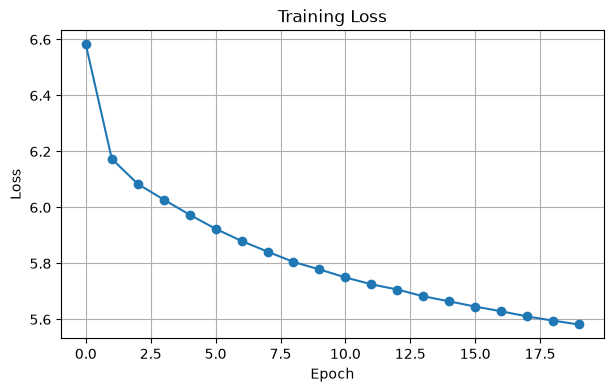

In [30]:
plt.figure(figsize=(7,4))

plt.plot(

    train_losses,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid(True)

plt.show()

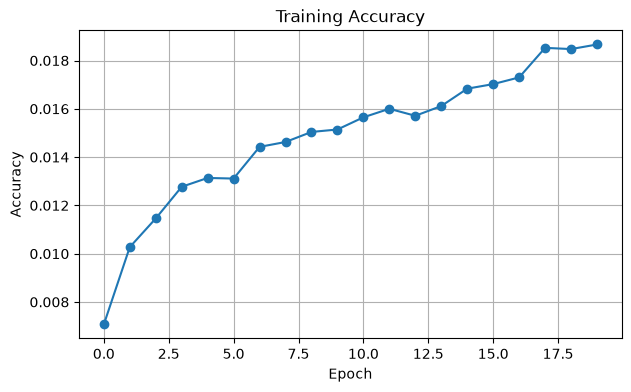

In [31]:
plt.figure(figsize=(7,4))

plt.plot(

    train_accuracies,

    marker="o"

)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("Training Accuracy")

plt.grid(True)

plt.show()

In [32]:
model.eval()

test_correct = 0

test_total = 0

all_predictions = []

all_targets = []

with torch.no_grad():

    for sequences, targets in test_loader:

        sequences = sequences.to(device)

        targets = targets.to(device)

        representation = model(

            sequences

        )

        scores = torch.matmul(

            representation,

            model.item_embedding.weight.T

        )

        scores[:, PAD_TOKEN] = -1e9

        predictions = scores.argmax(

            dim=1

        )

        test_correct += (

            predictions == targets

        ).sum().item()

        test_total += targets.size(0)

        all_predictions.extend(

            predictions.cpu().numpy()

        )

        all_targets.extend(

            targets.cpu().numpy()

        )

test_accuracy = test_correct / test_total

print(

    f"Test Accuracy : {test_accuracy:.4f}"

)

Test Accuracy : 0.0083


In [33]:
K = 10

model.eval()

hits = []

with torch.no_grad():

    for sequences, targets in test_loader:

        sequences = sequences.to(device)

        targets = targets.to(device)

        representation = model(

            sequences

        )

        scores = torch.matmul(

            representation,

            model.item_embedding.weight.T

        )

        scores[:, PAD_TOKEN] = -1e9

        topk = torch.topk(

            scores,

            K,

            dim=1

        ).indices

        hit = (

            topk == targets.unsqueeze(1)

        ).any(

            dim=1

        )

        hits.extend(

            hit.cpu().numpy()

        )

hitrate = np.mean(

    hits

)

print(

    f"HitRate@{K}: {hitrate:.4f}"

)

HitRate@10: 0.1022


In [34]:
K = 10

ndcg_scores = []

model.eval()

with torch.no_grad():

    for sequences, targets in test_loader:

        sequences = sequences.to(device)

        targets = targets.to(device)

        representation = model(

            sequences

        )

        scores = torch.matmul(

            representation,

            model.item_embedding.weight.T

        )

        scores[:, PAD_TOKEN] = -1e9

        topk = torch.topk(

            scores,

            K,

            dim=1

        ).indices

        for i in range(

            topk.size(0)

        ):

            ranking = topk[i]

            target = targets[i]

            if target in ranking:

                rank = (

                    ranking == target

                ).nonzero(

                    as_tuple=True

                )[0].item()

                ndcg = 1 / np.log2(

                    rank + 2

                )

            else:

                ndcg = 0

            ndcg_scores.append(

                ndcg

            )

ndcg = np.mean(

    ndcg_scores

)

print(

    f"NDCG@{K}: {ndcg:.4f}"

)

NDCG@10: 0.0465


In [35]:
print("="*40)

print(

    f"Test Accuracy : {test_accuracy:.4f}"

)

print(

    f"HitRate@10    : {hitrate:.4f}"

)

print(

    f"NDCG@10       : {ndcg:.4f}"

)

print("="*40)

Test Accuracy : 0.0083
HitRate@10    : 0.1022
NDCG@10       : 0.0465
